# N2 · 具身版 next-token: 状态 → 下一动作 token

> 配套 11.1-L3 · 训一个 tiny 模型, 给状态预测下一个动作 token (9 类分类 = next-token)。
> 然后用它当策略 rollout, 看学到的策略能不能到达目标。这是 RT-2「控制=预测token」的玩具内核。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import toy_env as env, action_serialize as ser
import numpy as np
import torch, torch.nn as nn
print('就绪')

就绪


## 1. 从专家 demo 学一个「状态→动作 token」预测器 (模仿学习)

In [2]:
torch.manual_seed(0)
S, A = env.make_demos(n=400, seed=0)
toks = np.array([ser.action_to_token(a) for a in A], dtype=np.int64)
X = torch.tensor(S); Y = torch.tensor(toks)
# tiny 策略网络: state(4) → 9 个动作 token 的 logits (具身版 next-token 预测头)
policy = nn.Sequential(nn.Linear(env.STATE_DIM, 64), nn.SiLU(),
                       nn.Linear(64, 64), nn.SiLU(),
                       nn.Linear(64, ser.N_ACTION_TOKENS))
opt = torch.optim.Adam(policy.parameters(), lr=3e-3)
for ep in range(400):
    logits = policy(X)
    loss = nn.functional.cross_entropy(logits, Y)
    opt.zero_grad(); loss.backward(); opt.step()
acc = (policy(X).argmax(-1) == Y).float().mean().item()
print(f'训练 loss {loss.item():.3f}, 训练集动作 token 准确率 {acc:.2f}')

训练 loss 0.025, 训练集动作 token 准确率 1.00


## 2. 用学到的策略 rollout: 它能走到目标吗?

学到的策略成功率: 1.00  (专家上界 1.00)


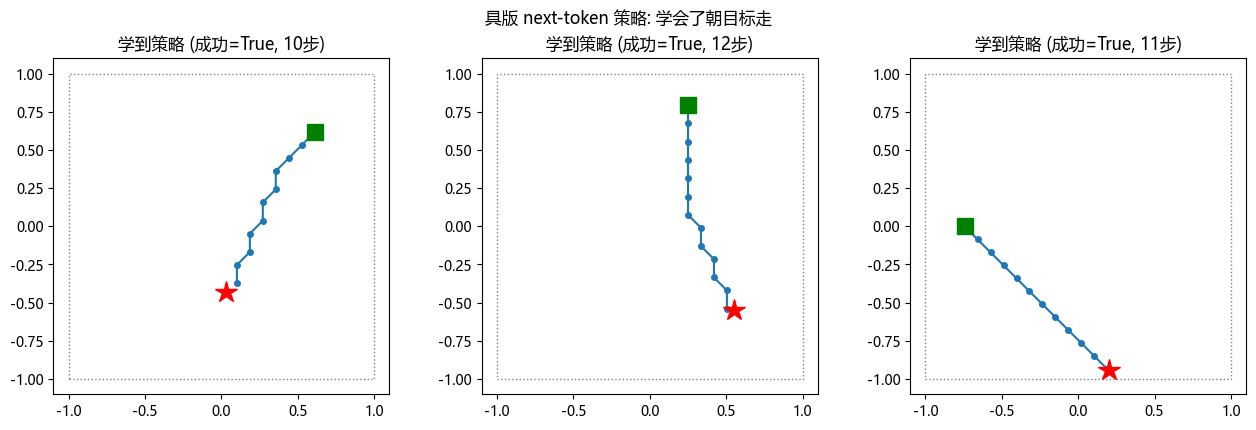

→ 一个 next-action 预测器 = 一个能用的策略。这就是 RT-2 的玩具内核 (控制=预测token)。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
def learned_policy(state):
    with torch.no_grad():
        tok = policy(torch.tensor(state[None], dtype=torch.float32)).argmax(-1).item()
    return ser.token_to_action(tok)

sr = env.eval_policy(learned_policy, n_episodes=200)
sr_expert = env.eval_policy(env.expert_action, n_episodes=200)
print(f'学到的策略成功率: {sr:.2f}  (专家上界 {sr_expert:.2f})')
# 画几条学到策略的轨迹
fig, axes = plt.subplots(1, 3, figsize=(13,4.2))
for ax, seed in zip(axes, [5, 7, 11]):
    ok, steps, traj = env.rollout(learned_policy, seed=seed, record=True)
    traj = np.array(traj)
    ax.plot(traj[:,0], traj[:,1], '-o', ms=4)
    ax.plot(traj[0,0], traj[0,1], 'gs', ms=12); ax.plot(traj[0,2], traj[0,3], 'r*', ms=16)
    ax.add_patch(plt.Rectangle((-1,-1),2,2,fill=False,ls=':',ec='gray'))
    ax.set_title(f'学到策略 (成功={ok}, {steps}步)'); ax.set_aspect('equal')
plt.suptitle('具版 next-token 策略: 学会了朝目标走'); plt.tight_layout(); plt.show()
print('→ 一个 next-action 预测器 = 一个能用的策略。这就是 RT-2 的玩具内核 (控制=预测token)。')

## 3. 反思 (11.1 收口)

你训了一个「状态→下一动作 token」预测器, 它就是一个能到达目标的策略。带走:
- **控制 = next-token 预测**: 和你 LLM 一模一样的机制 (CE 训练 + argmax 解码), 只是 token 是动作。
- **模仿学习**: 从专家 demo 学策略 = 监督学习 (M11.4 会深入)。
- 离散动作 token 够走到目标, 但精度受限于离散化 (推动 M11.3 连续/扩散动作头)。

> **M11.1 收口**: 具身闭环 + tokens-as-actions + 数据正迁移; 控制能当 next-token 做 = 复用你 LLM 全套。
> **交棒 M11.2「vla-architectures」**: 把感知核换成真正的 VLM —— 用 M10 的 mini-VLM + 动作头组装 mini-VLA。下一专题 `vla-architectures`。